# Calculate the Polarimetric Accuracy of the Model

Finally, you can calculate the theoretical uncertainties on measure the degree and angle of linear polarization from your data and model, $s_p$ and $s_{\chi}$. You do this by propagating together $s_{rel}$ and $s_{abs}$ with the DoLP and AoLP of a theoretical target.

# Step 1: Load in $s_{rel}$ and $s_{abs}$

NOTE: This calculation was derived from Appendix E of the van Holstein 2020 SPHERE/IRDIS calibration. $s_{abs}$ includes effects from unpolarized internal calibrations via this derivation. However, these effects are often negligible due to double differencing. It is up to user discretion whether to set $s_{abs}=s_{sky}$ (as in the Hart et al. 2021 CHARIS calibration) or to do the procedure I do below, where I account for $s_{unpol}$ using the results from the fit in `CHARIS.minimize.minimize_onsky_unpol_july2025.ipynb`.

In [1]:
# Loading in calculations from global fit notebooks
import numpy as np

with open('s_rel.txt', 'r') as f:
    s_rel = [float(x) for x in f.read().splitlines()]

with open('s_sky.txt', 'r') as f:
    s_sky = [float(x) for x in f.read().splitlines()]

with open('s_unpol.txt', 'r') as f:
    s_unpol = [float(x) for x in f.read().splitlines()]

s_abs = np.hypot(s_sky, s_unpol)  # Calculate absolute polarimetric accuracy

# Step 2: Calculate $s_p$ and $s_{\chi}$

These are the errors introduced for the DoLP and AoLP from model uncertainty

In [2]:
from pyPolCal.fitting import calc_polarimetric_accuracy
# Calculating for a 1% polarized target
s_p, s_chi = calc_polarimetric_accuracy(s_abs,s_rel, p=1, chi_deg=50)
print(s_p)
print(s_chi)

/home/thomasmc/miniconda3/envs/charisenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[0.03893485 0.0442255  0.03503881 0.03260192 0.03974839 0.1105053
 0.05339151 0.04493665 0.0378293  0.04156054 0.05312983 0.06208868
 0.043166   0.05985442 0.07842608 0.04827091 0.04410876 0.01898953
 0.03970291 0.05148182 0.03688046 0.07378734]
[0.99909829 1.17873246 0.9455928  0.89541028 1.08476036 3.14993012
 1.51734342 1.27002732 1.06483441 1.17345135 1.50141438 1.75891404
 1.22123961 1.69842197 2.2322106  1.36856956 1.25191991 0.53212076
 1.12695309 1.46298254 1.03992906 2.09695182]


Text(0, 0.5, '$s_p$ (%)')

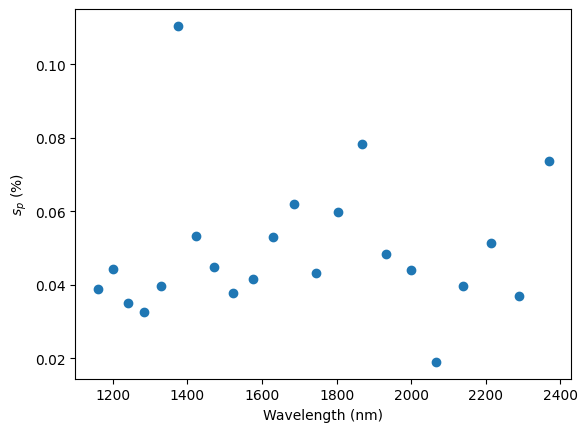

In [3]:
from pyPolCal.constants import wavelength_bins
import matplotlib.pyplot as plt

plt.scatter(wavelength_bins, s_p, label='s_p')
plt.xlabel('Wavelength (nm)')
plt.ylabel('$s_p$ (%)')

Text(0, 0.5, '$s_{\\chi}$ ($^\\circ$)')

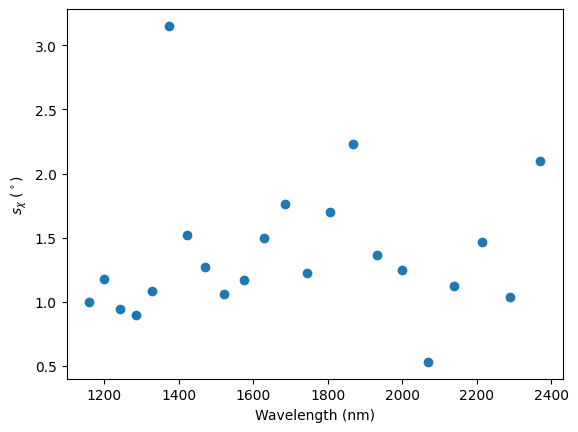

In [4]:
plt.scatter(wavelength_bins, s_chi, label='s_chi')
plt.xlabel('Wavelength (nm)')
plt.ylabel('$s_{\chi}$ ($^\circ$)')